## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [1]:
# imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

## Running qsoabsfind as `bash` script

### Details of input file (DESI DR1 Spectra)

In [2]:
# exploring ..data/desi/qso_test_spectra.fits file
hdul = fits.open(f'../data/desi/qso_test_spectra.fits')
hdul[0].header
hdul.close()

I have already run `qsoabsfind` on `../data/desi/qso_test_spectra.fits` and saved the results as `../data/desi/MgII_cat.fits`. In case you want to run, please do it by changing the `--output`

### Exploring output

Text(0.5, 0, 'MgII redshift')

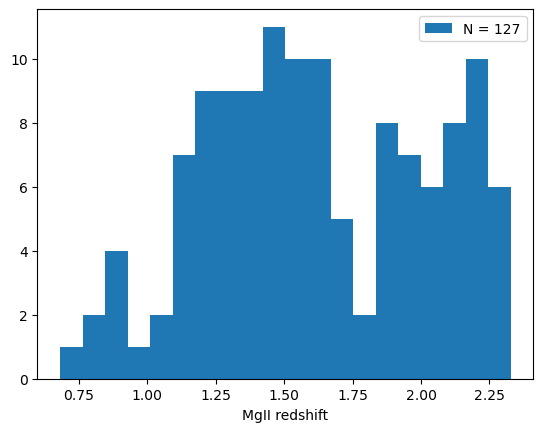

In [3]:
mgii_tab = Table.read(f'../data/desi/MgII_cat.fits', hdu=1)
zabs = mgii_tab["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

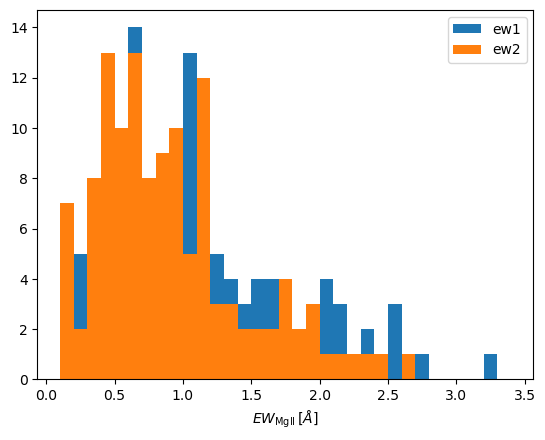

In [4]:
ew1 = mgii_tab["MGII_2796_EW"].data
ew2 = mgii_tab["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.07 seconds



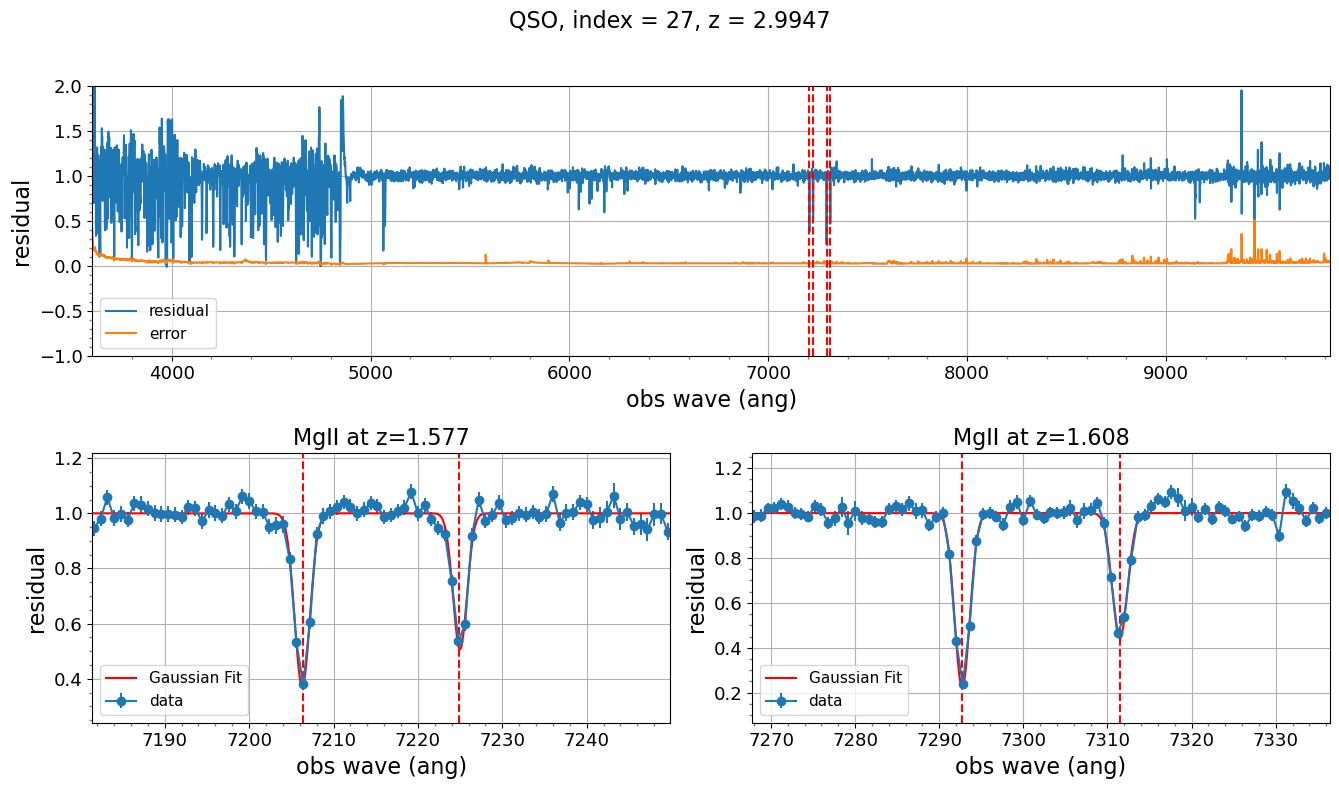

In [5]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = np.random.choice(mgii_tab["INDEX_SPEC"].data)
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab[mgii_tab["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z"]:.4f}', plot_filename=None)

### Using qsoabsfind internally as module

In [6]:
# if want to run qsoabsfind on one spectrum
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.constants import search_parameters
help(read_single_spectrum_and_find_absorber)

Help on function read_single_spectrum_and_find_absorber in module qsoabsfind.absfinder:

read_single_spectrum_and_find_absorber(fits_file, spec_index, absorber, **kwargs)
    This function retrieves a single QSO spectrum from a FITS file, processes the data to remove NaNs,
    and prepares the spectrum for absorber search within specified wavelength regions
    and runs the convolution based adaptive S/N method to detect absorbers in the spectrum.
    
    Args:
        fits_file (str): Path to the FITS file containing normalized QSO spectra.
                         The file must include extensions for FLUX, ERROR, WAVELENGTH
                         and METADATA which must contain keyword Z_QSO.
        spec_index (int): Index of the quasar spectrum to retrieve from the FITS file.
        absorber (str): Name of the absorber to search for (e.g., 'MgII', 'CIV').
        kwargs (dict): search parameters as described in qsoabsfind.constants()
    
    Returns:
        tuple: Contains li

In [7]:
read_single_spectrum_and_find_absorber(f'../data/desi/qso_test_spectra.fits', 362, 'CIV', **search_parameters["CIV"])

INFO: Starting search for QSO INDEX = 362
INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.07 seconds

INFO: final wave window selection for CIV took 0.00 seconds

INFO: search absorber = CIV
INFO: Z_qso = 3.36271381444273
INFO: instrumental resolution will be calculated from wavelength array, it is assumed that wavelength pixels are less than FWHM, so will not divide by 2.355
INFO: mean wave_resolution = 0.80000, mean resolution per pixel  = 38.708 [km/s]


INFO: Time taken to finish CIV detection for index = 362 Quasar is: 
 3.71 seconds



([362],
 [2.8907521351469345],
 [[0.45402296940462844,
   1548.215504270079,
   0.44871813872522326,
   0.2885406199266654,
   1550.7544699928608,
   0.37045039484047226]],
 [[0.01572226741841685,
   0.018618765949019705,
   0.018788269775121835,
   0.0177601934636073,
   0.026703042015604285,
   0.026964160543378295]],
 [0.5106711983680725],
 [0.2679334580898285],
 [0.7786046862602234],
 [0.003698378335684538],
 [0.0030104226898401976],
 [0.004768715240061283],
 [4.085881664650515e-05],
 [26.121692180476614],
 [13.560414444771245],
 [77.28397693662035],
 [59.61267048048186])

Text(0.5, 0, 'CIV redshift')

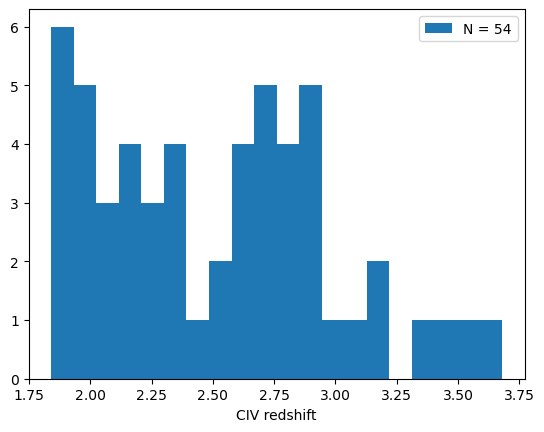

In [8]:
abs_tab = Table.read(f'../data/desi/CIV_cat.fits', hdu=1)
zabs = abs_tab["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.07 seconds



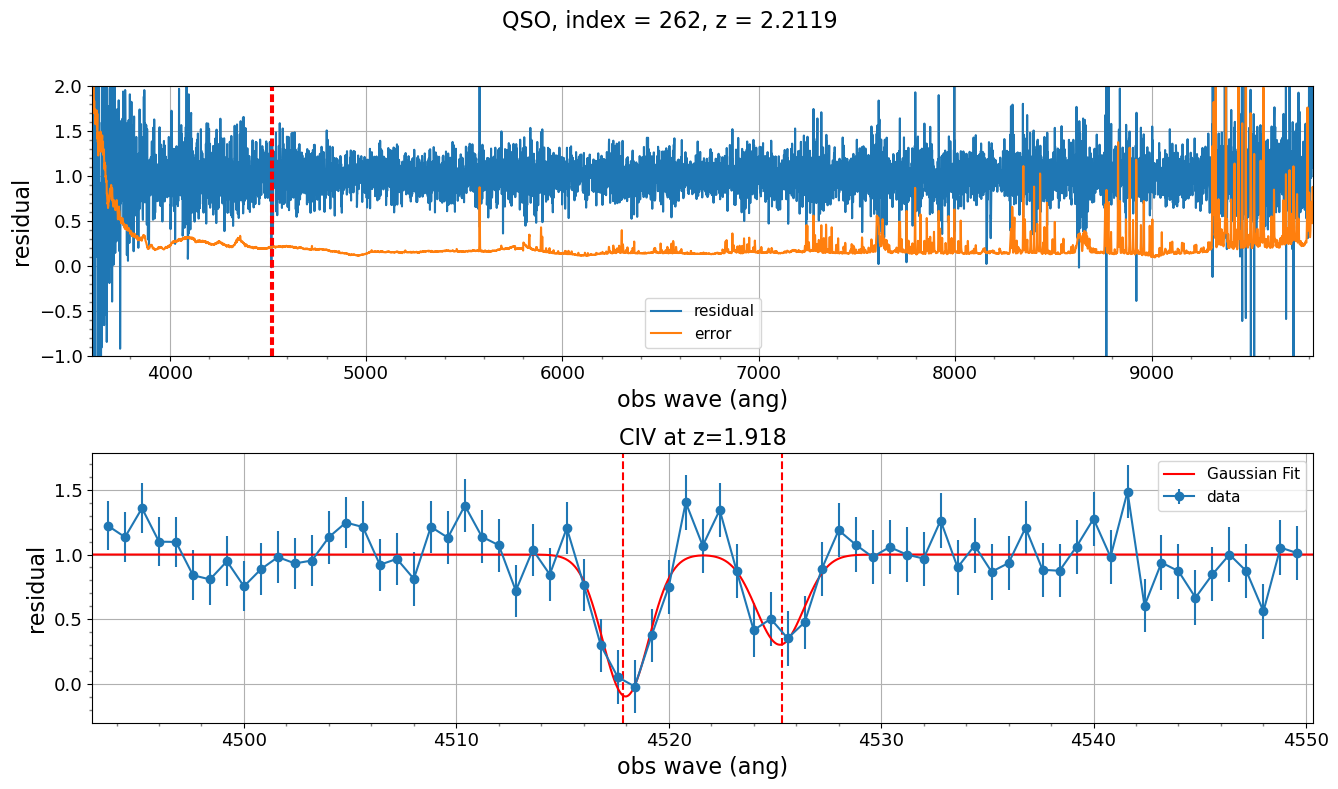

In [9]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead

# select a random spectra from MgII_cat.fits
index = np.random.choice(abs_tab["INDEX_SPEC"].data)
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = abs_tab[abs_tab["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'CIV', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z"]:.4f}', plot_filename=None)